In [1]:
import cv2
import matplotlib.pyplot as plt

In [2]:
import sys

sys.path.append('..')

In [3]:
from src.datasets.images_dataset import AlzheimersDataset

In [4]:
data = AlzheimersDataset()

In [15]:
total_count = len(data.filter(patient_ids=["0001","0002", "0003"]).groupby(by='patient_id').grouped['0001'])

In [ ]:
total_count #grouby(patient_id).count()

208

In [9]:
data.filter().groupby(by='label_str').count()

{'non': 63560, 'very-mild': 13796, 'mild': 5184, 'moderate': 376}

In [15]:
data.filter(distinct_patients=True).groupby(by='label_str').count()

{'non': 316, 'very-mild': 70, 'mild': 28, 'moderate': 2}

In [8]:
slice_data = data.filter(label='moderate').groupby(by=['patient_id', 'scan_id']).grouped

slice_data

{('0308',
  'MR1_1'): [AlzheimerDataSetAtom(patient_id='0308', scan_id='MR1_1', slice_num=129, path='c:\\Users\\Jivesh Gawde\\Documents\\NMIMS\\NeuroTrack\\src\\data\\alzheimers-data\\ModerateDemented\\ModerateDemented\\OAS1_0308_MR1_1.nii_slice_129.png', label=3, label_str='moderate'), AlzheimerDataSetAtom(patient_id='0308', scan_id='MR1_1', slice_num=130, path='c:\\Users\\Jivesh Gawde\\Documents\\NMIMS\\NeuroTrack\\src\\data\\alzheimers-data\\ModerateDemented\\ModerateDemented\\OAS1_0308_MR1_1.nii_slice_130.png', label=3, label_str='moderate'), AlzheimerDataSetAtom(patient_id='0308', scan_id='MR1_1', slice_num=131, path='c:\\Users\\Jivesh Gawde\\Documents\\NMIMS\\NeuroTrack\\src\\data\\alzheimers-data\\ModerateDemented\\ModerateDemented\\OAS1_0308_MR1_1.nii_slice_131.png', label=3, label_str='moderate'), AlzheimerDataSetAtom(patient_id='0308', scan_id='MR1_1', slice_num=132, path='c:\\Users\\Jivesh Gawde\\Documents\\NMIMS\\NeuroTrack\\src\\data\\alzheimers-data\\ModerateDemented\\Mod

In [ ]:
slice_count_data = data.filter(label='moderate').groupby(by=['patient_id', 'scan_id']).count()

slice_count_data

{('0308', 'MR1_1'): 40,
 ('0308', 'MR1_2'): 48,
 ('0308', 'MR1_3'): 40,
 ('0308', 'MR1_4'): 40,
 ('0351', 'MR1_1'): 48,
 ('0351', 'MR1_2'): 56,
 ('0351', 'MR1_3'): 56,
 ('0351', 'MR1_4'): 48}

In [ ]:
first_slice_data = data.filter(label='moderate').groupby(by=['patient_id', 'scan_id']).first()

first_slice = [(_,i.slice_num) for _,i in first_slice_data.items()]

first_slice

# first_slice_data

[(('0308', 'MR1_1'), 129),
 (('0308', 'MR1_2'), 127),
 (('0308', 'MR1_3'), 133),
 (('0308', 'MR1_4'), 131),
 (('0351', 'MR1_1'), 145),
 (('0351', 'MR1_2'), 135),
 (('0351', 'MR1_3'), 133),
 (('0351', 'MR1_4'), 139)]

In [5]:
last_slice_data = data.filter(label='moderate').groupby(by=['patient_id', 'scan_id']).last()

last_slice = [(_,i.slice_num) for _,i in last_slice_data.items()]

last_slice

# first_slice_data

[(('0308', 'MR1_1'), 168),
 (('0308', 'MR1_2'), 174),
 (('0308', 'MR1_3'), 172),
 (('0308', 'MR1_4'), 170),
 (('0351', 'MR1_1'), 192),
 (('0351', 'MR1_2'), 190),
 (('0351', 'MR1_3'), 188),
 (('0351', 'MR1_4'), 186)]

In [5]:
data.filter(label='moderate').groupby(by=['patient_id', 'scan_id']).min('slice_num')

{('0308',
  'MR1_1'): AlzheimerDataSetAtom(patient_id='0308', scan_id='MR1_1', slice_num=129, path='c:\\Users\\Jivesh Gawde\\Documents\\NMIMS\\NeuroTrack\\src\\data\\alzheimers-data\\ModerateDemented\\ModerateDemented\\OAS1_0308_MR1_1.nii_slice_129.png', label=3, label_str='moderate'),
 ('0308',
  'MR1_2'): AlzheimerDataSetAtom(patient_id='0308', scan_id='MR1_2', slice_num=127, path='c:\\Users\\Jivesh Gawde\\Documents\\NMIMS\\NeuroTrack\\src\\data\\alzheimers-data\\ModerateDemented\\ModerateDemented\\OAS1_0308_MR1_2.nii_slice_127.png', label=3, label_str='moderate'),
 ('0308',
  'MR1_3'): AlzheimerDataSetAtom(patient_id='0308', scan_id='MR1_3', slice_num=133, path='c:\\Users\\Jivesh Gawde\\Documents\\NMIMS\\NeuroTrack\\src\\data\\alzheimers-data\\ModerateDemented\\ModerateDemented\\OAS1_0308_MR1_3.nii_slice_133.png', label=3, label_str='moderate'),
 ('0308',
  'MR1_4'): AlzheimerDataSetAtom(patient_id='0308', scan_id='MR1_4', slice_num=131, path='c:\\Users\\Jivesh Gawde\\Documents\\NMI

In [6]:
data.filter(label='moderate').groupby(by=['patient_id', 'scan_id']).max('slice_num')

{('0308',
  'MR1_1'): AlzheimerDataSetAtom(patient_id='0308', scan_id='MR1_1', slice_num=168, path='c:\\Users\\Jivesh Gawde\\Documents\\NMIMS\\NeuroTrack\\src\\data\\alzheimers-data\\ModerateDemented\\ModerateDemented\\OAS1_0308_MR1_1.nii_slice_168.png', label=3, label_str='moderate'),
 ('0308',
  'MR1_2'): AlzheimerDataSetAtom(patient_id='0308', scan_id='MR1_2', slice_num=174, path='c:\\Users\\Jivesh Gawde\\Documents\\NMIMS\\NeuroTrack\\src\\data\\alzheimers-data\\ModerateDemented\\ModerateDemented\\OAS1_0308_MR1_2.nii_slice_174.png', label=3, label_str='moderate'),
 ('0308',
  'MR1_3'): AlzheimerDataSetAtom(patient_id='0308', scan_id='MR1_3', slice_num=172, path='c:\\Users\\Jivesh Gawde\\Documents\\NMIMS\\NeuroTrack\\src\\data\\alzheimers-data\\ModerateDemented\\ModerateDemented\\OAS1_0308_MR1_3.nii_slice_172.png', label=3, label_str='moderate'),
 ('0308',
  'MR1_4'): AlzheimerDataSetAtom(patient_id='0308', scan_id='MR1_4', slice_num=170, path='c:\\Users\\Jivesh Gawde\\Documents\\NMI

In [ ]:
path_data = data.filter().groupby('label_str').first()

path_info_dict = {k: i.path for k, i in path_data.items()}

path_info_dict

{'non': 'c:\\Users\\Jivesh Gawde\\Documents\\NMIMS\\NeuroTrack\\src\\data\\alzheimers-data\\NonDemented (2)\\NonDemented\\OAS1_0001_MR1_1.nii_slice_121.png',
 'very-mild': 'c:\\Users\\Jivesh Gawde\\Documents\\NMIMS\\NeuroTrack\\src\\data\\alzheimers-data\\VeryMildDemented\\VeryMildDemented\\OAS1_0003_MR1_1.nii_slice_137.png',
 'mild': 'c:\\Users\\Jivesh Gawde\\Documents\\NMIMS\\NeuroTrack\\src\\data\\alzheimers-data\\MildDemented\\MildDemented\\OAS1_0028_MR1_1.nii_slice_113.png',
 'moderate': 'c:\\Users\\Jivesh Gawde\\Documents\\NMIMS\\NeuroTrack\\src\\data\\alzheimers-data\\ModerateDemented\\ModerateDemented\\OAS1_0308_MR1_1.nii_slice_129.png'}

In [60]:
same_slice_data = data.filter(distinct_patients=True, distinct_patients_strategy="last").groupby(by='label_str').first()

slice_info_dict = {_: i.path for _, i in same_slice_data.items()} 

slice_info_dict


{'non': 'c:\\Users\\Jivesh Gawde\\Documents\\NMIMS\\NeuroTrack\\src\\data\\alzheimers-data\\NonDemented (2)\\NonDemented\\OAS1_0001_MR1_3.nii_slice_164.png',
 'very-mild': 'c:\\Users\\Jivesh Gawde\\Documents\\NMIMS\\NeuroTrack\\src\\data\\alzheimers-data\\VeryMildDemented\\VeryMildDemented\\OAS1_0003_MR1_3.nii_slice_188.png',
 'mild': 'c:\\Users\\Jivesh Gawde\\Documents\\NMIMS\\NeuroTrack\\src\\data\\alzheimers-data\\MildDemented\\MildDemented\\OAS1_0028_MR1_2.nii_slice_174.png',
 'moderate': 'c:\\Users\\Jivesh Gawde\\Documents\\NMIMS\\NeuroTrack\\src\\data\\alzheimers-data\\ModerateDemented\\ModerateDemented\\OAS1_0308_MR1_2.nii_slice_174.png'}

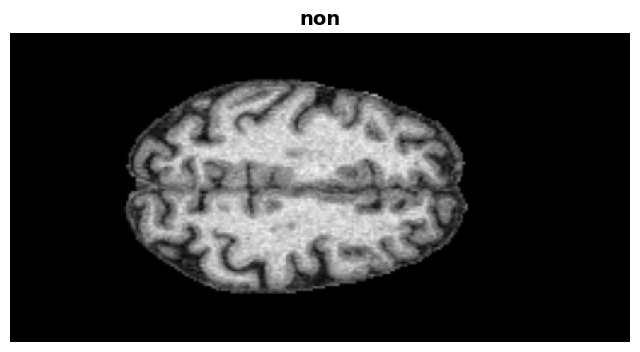

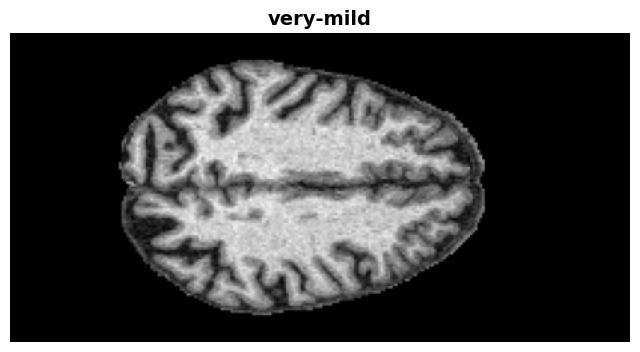

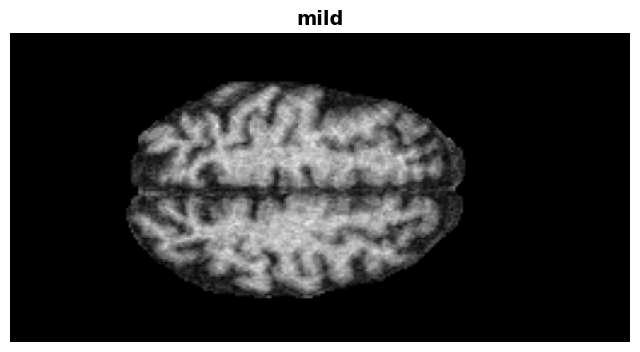

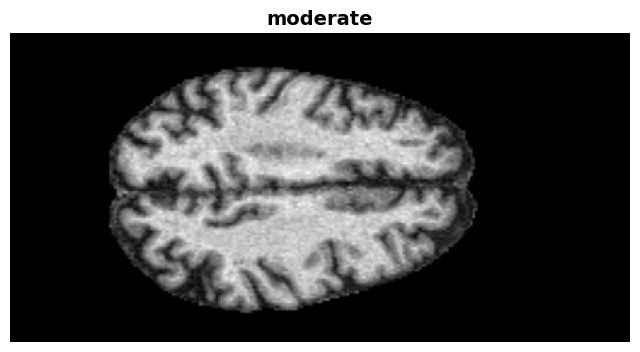

In [61]:
for dementia_type, image_path in slice_info_dict.items():

    img = cv2.imread(image_path)

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    plt.figure(figsize=(8, 6))
    plt.imshow(img_rgb)
    plt.title(dementia_type, fontsize=14, fontweight='bold')
    plt.axis('off')
    plt.show()